# Trabajo Práctico de Estadística

In [ ]:
from datetime import datetime
import pandas as pd
import numpy as np
import gc
from typing import Callable
import time
from itertools import product
import matplotlib.pyplot as plt
import scipy as sp
from statsmodels.api import OLS, add_constant
from statsmodels.stats.diagnostic import lilliefors


# Estadística Descriptiva


## Ejercicio 1


In [ ]:
output_file = "bench_fib.json"
batch_sizes = [1, 5, 10, 50]
ns = [2, 4, 10, 20, 30]
combinations = product(ns, batch_sizes)
runs = 500

## Ejercicio 2
Observemos cómo se ve la distribución de los tiempos para $n = 20$ y $m = 10$.


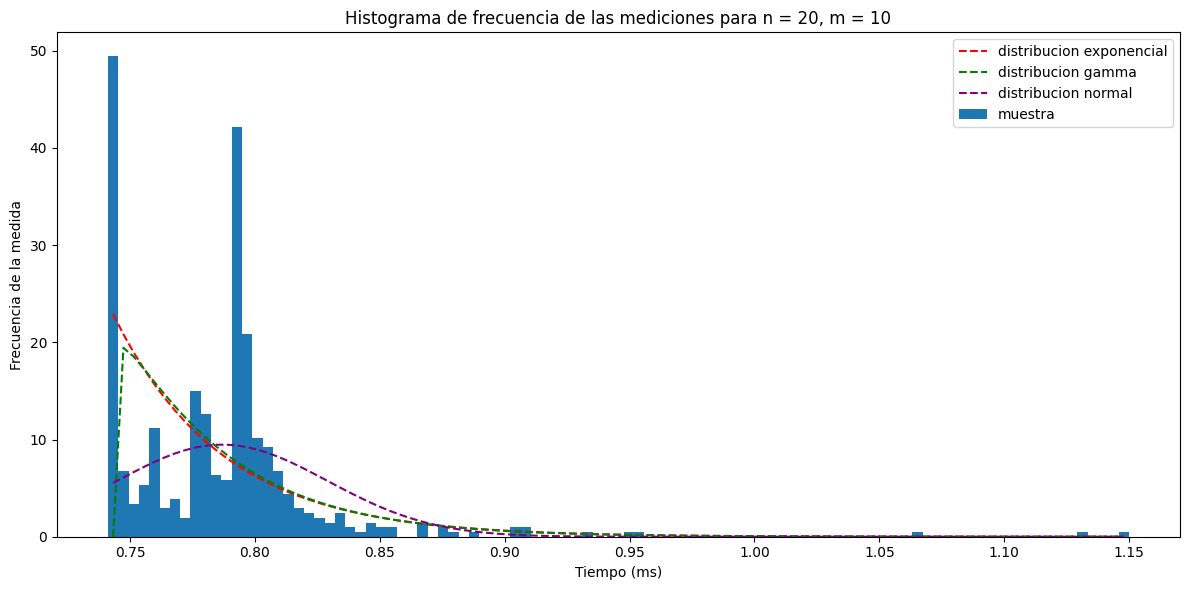

In [ ]:
n = 20
m = 10
df = pd.read_json("bench_fib.json")


def obtener_medidas_de(n, m):
    data = df[(df['n'] == n) & (df['batch_size'] == m)]
    medidas = data['time_ms']
    return medidas

def hacer_histograma(data, n, m, bins=None):
    medidas = obtener_medidas_de(n, m)


    if bins is None:
        maximo = np.max(medidas)
        minimo = np.min(medidas)
        tam = maximo - minimo
        bins = np.linspace(minimo, maximo, 100)

    h, b = np.histogram(medidas, bins=bins, density=True)
    return h, b



medidas = obtener_medidas_de(n, m)
h, b = hacer_histograma(df, n, m)

plt.figure(figsize=(12, 6))
plt.bar(b[:-1], h, width=b[1]-b[0], label="muestra", align='center', fill=True)

# Se asemeja a la distribucion exponencial,
# usamos el estimador del primer momento para beta
# Como en este caso esta shifteado por el valor minimo
# restamos el valor minimo (b[0]) para calcular la media
# y para evaluar la funcion
medidas_shifteadas = medidas - b[0]
media = np.mean(medidas_shifteadas)
var = np.std(medidas_shifteadas) ** 2
x = b[:-1] - b[0]
y_exponencial = (1/media) * np.exp(-x/media)
plt.plot(b[:-1], y_exponencial, 'r--', label="distribucion exponencial")

# Usamos los estimadores del primer y segundo momento para obtener alpha y beta
beta = var / media
alpha = media / beta
y_gamma = np.power(x, alpha - 1) * np.exp(-x/beta) / (sp.special.gamma(alpha) * np.power(beta, alpha))
plt.plot(b[:-1], y_gamma, 'g--', label="distribucion gamma")

sigma = np.sqrt(var)
y_normal = np.exp(-((x - media)**2) / (2*var)) / (np.sqrt(2 * np.pi) * sigma)
plt.plot(b[:-1], y_normal, '--', label="distribucion normal", color="purple")

plt.title(f"Histograma de frecuencia de las mediciones para n = {n}, m = {m}")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Frecuencia de la medida")
plt.legend()
plt.tight_layout()
plt.show()

Usando estimadores del primer y segundo momento para aproximar los parámetros, se ve bastante similar a una distribución exponencial o gamma, con algo de ruido, no tanto a una distribución normal.

Hagamos otras comparaciones para visualizarlo.

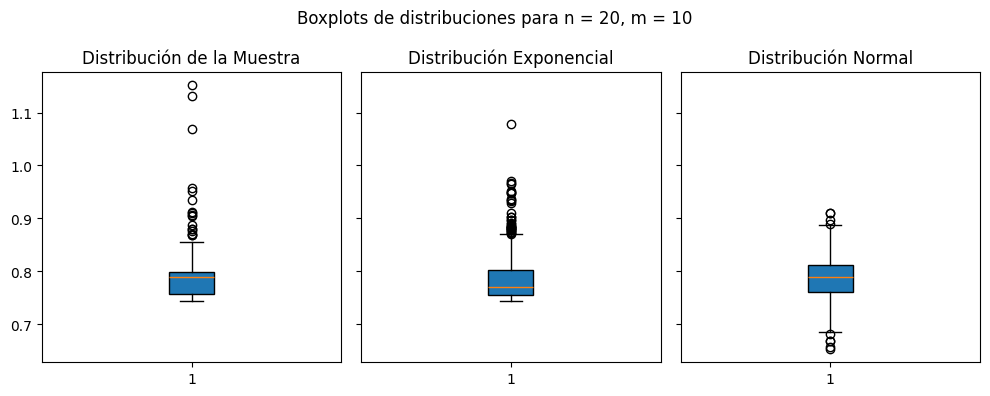

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
axs[0].boxplot(medidas, vert=True, patch_artist=True)
axs[0].set_title(f"Distribución de la Muestra")

np.random.seed(2025)

beta = np.mean(medidas - np.min(medidas))
exponencial = np.random.exponential(beta, size=len(medidas)) + np.min(medidas)
axs[1].boxplot(exponencial, vert=True, patch_artist=True)
axs[1].set_title("Distribución Exponencial")

mu = np.mean(medidas)
sigma = np.std(medidas)
normal = np.random.normal(mu, sigma, size=len(medidas))
axs[2].boxplot(normal, vert=True, patch_artist=True)
axs[2].set_title("Distribución Normal")

plt.suptitle(f"Boxplots de distribuciones para n = {n}, m = {m}")
plt.tight_layout()
plt.show()

Aunque no es igual, observamos que el boxplot de la muestra es mucho más similar al de la distribución exponencial que al de la distribución normal.

Esto incluye comportamientos como tener una media más cerca de sus valores bajos, que la mayoría de los outliers estén en los valores altos y que en general se concentra en los valores bajos.

Observemos la distribución para otros valores de $n$ y $m$.

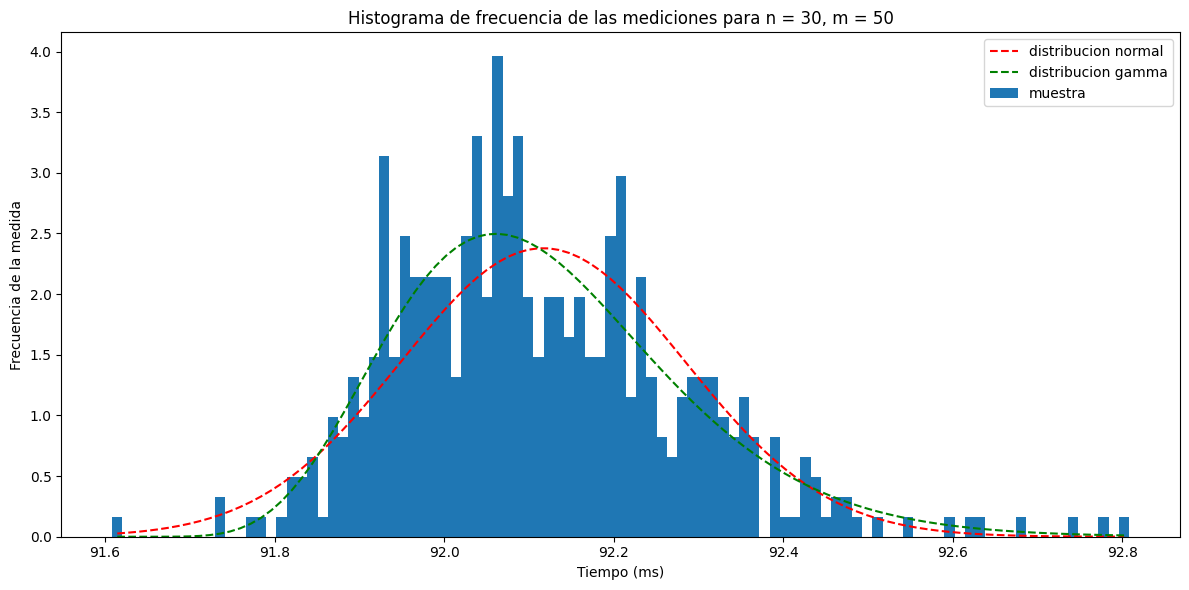

In [ ]:
n = 30
m = 50
medidas = obtener_medidas_de(n, m)
h, b = hacer_histograma(df, n, m)

plt.figure(figsize=(12, 6))
plt.bar(b[:-1], h, width=b[1]-b[0], label="muestra", align='center', fill=True)

medidas_shifteadas = medidas - b[0]
media = np.mean(medidas_shifteadas)
var = np.std(medidas_shifteadas) ** 2
x = b[:-1] - b[0]

sigma = np.sqrt(var)
y_normal = np.exp(-((x - media)**2) / (2*var)) / (np.sqrt(2 * np.pi) * sigma)
plt.plot(b[:-1], y_normal, 'r--', label="distribucion normal")

# Usamos los estimadores del primer y segundo momento para obtener alpha y beta
beta = var / media
alpha = media / beta
y_gamma = np.power(x, alpha - 1) * np.exp(-x/beta) / (sp.special.gamma(alpha) * np.power(beta, alpha))
plt.plot(b[:-1], y_gamma, 'g--', label="distribucion gamma")

plt.title(f"Histograma de frecuencia de las mediciones para n = {n}, m = {m}")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Frecuencia de la medida")
plt.legend()
plt.tight_layout()
plt.show()

Por otro lado, cuando trabajamos con un $n$ y $m$ más grandes (30 y 50 respectivamente), se aleja bastante de la distribución exponencial y se acerca más a la distribución normal. Sin embargo, parece ser más similar a la distribución gamma que la distribución normal.

Elegimos mostrar solo algunas distribuciones porque de ver las distribuciones para todos los casos a la vez, no podríamos verlos en detalle. Sin embargo viendo solo algunos gráficos hay información faltante, así que grafiquemos todas las distribuciones.

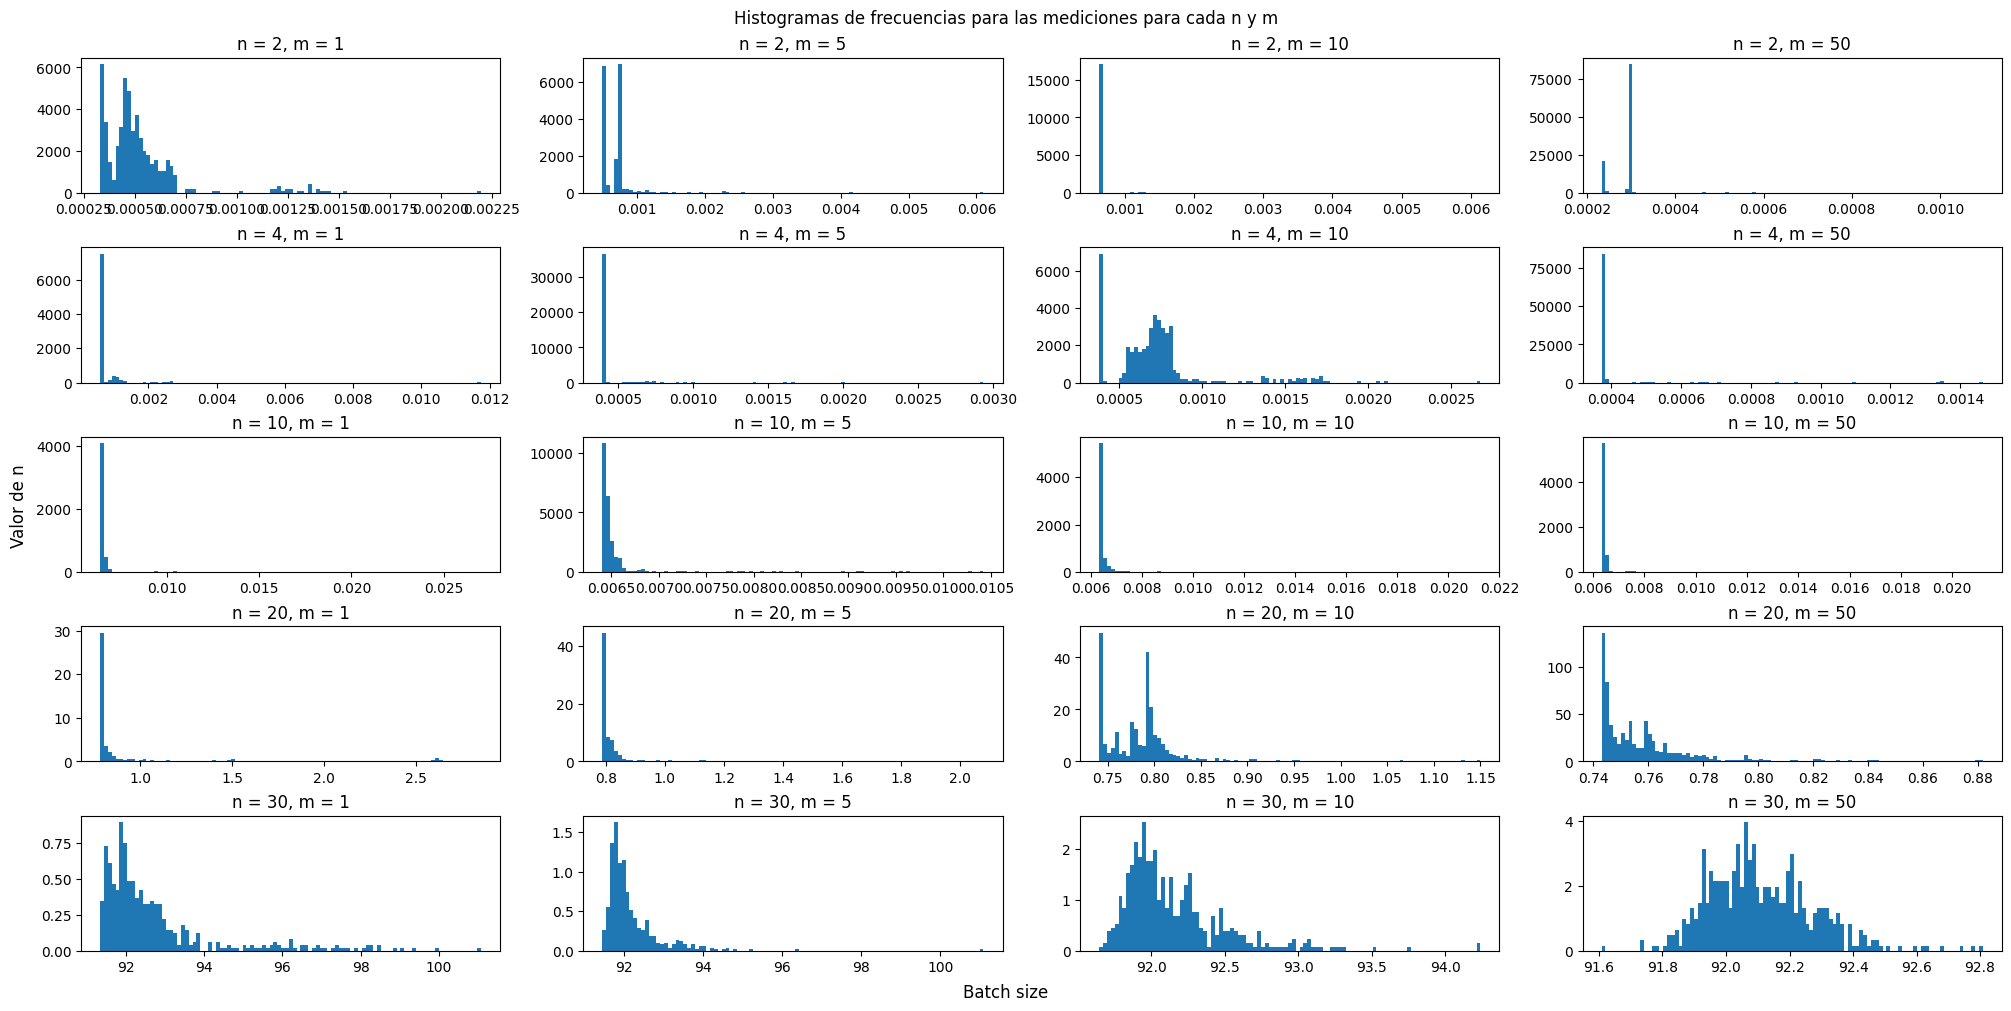

In [ ]:
fig, axs = plt.subplots(len(ns), len(batch_sizes), figsize=(20, 10), constrained_layout=True)

for (i, n) in enumerate(ns):
    for (j, m) in enumerate(batch_sizes):
        h, b = hacer_histograma(df, n, m)
        axs[i][j].bar(b[:-1], h, width=b[1]-b[0], label="muestra", align='center', fill=True)
        axs[i][j].set_title(f"n = {n}, m = {m}")

fig.suptitle("Histogramas de frecuencias para las mediciones para cada n y m")
fig.supxlabel("Batch size")
fig.supylabel("Valor de n")
plt.show()

## Ejercicio 3

Analicemos las distribuciones para varios $m$ fijando $n = 20$.

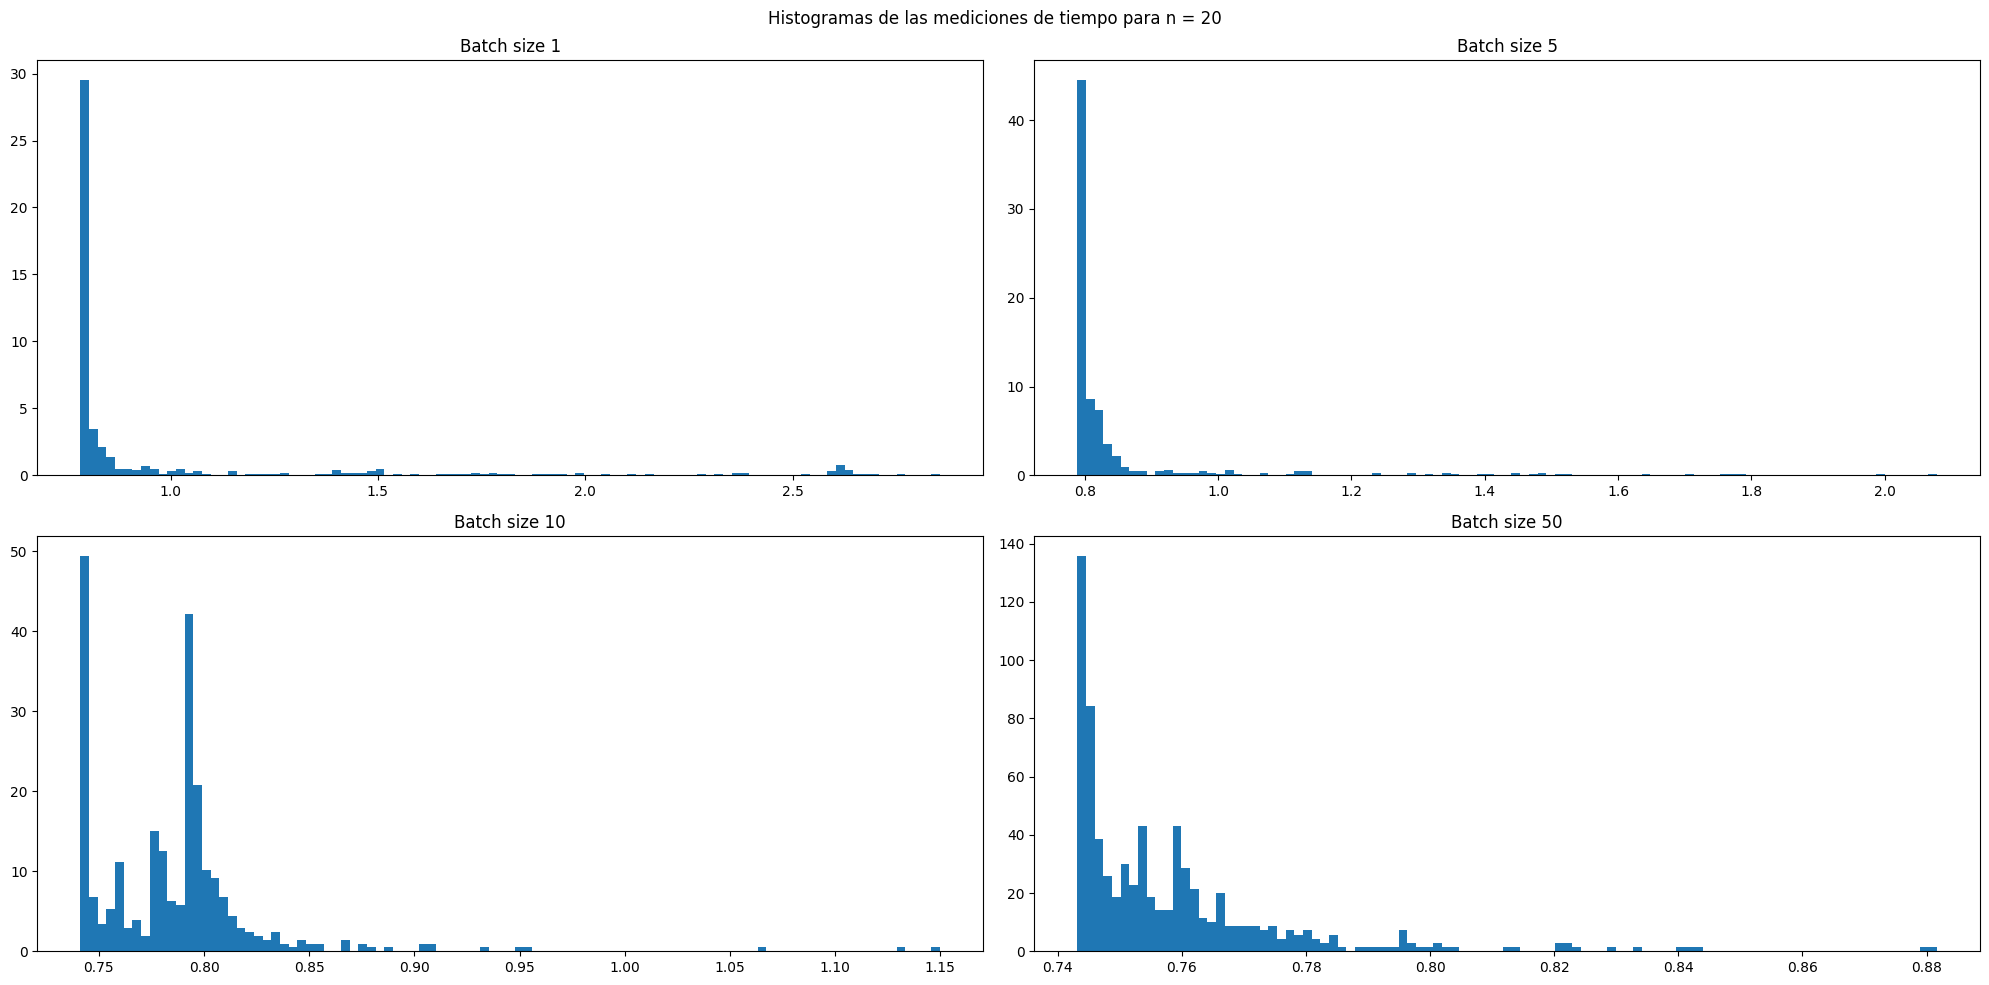

In [ ]:
n = 20
fig, axs = plt.subplots(2, 2, figsize=(20, 10))

colors = ['red', 'blue', 'green', 'purple']

for i in range(len(batch_sizes)):
    h, b = hacer_histograma(df, n, batch_sizes[i])
    axs[i // 2][i % 2].bar(b[:-1], h, width=b[1]-b[0], label="muestra", align='center', fill=True)
    axs[i // 2][i % 2].set_title(f"Batch size {batch_sizes[i]}")

plt.suptitle(f"Histogramas de las mediciones de tiempo para n = {n}")
plt.tight_layout()
plt.show()

Con estos ejemplos podemos ver como al aumentar el batch size $(m)$, la variabilidad baja considerablemente, pues los rangos se vuelven mucho más pequeños.

Podemos comparar los valores más frecuentes para no analizar tanto los outliers.

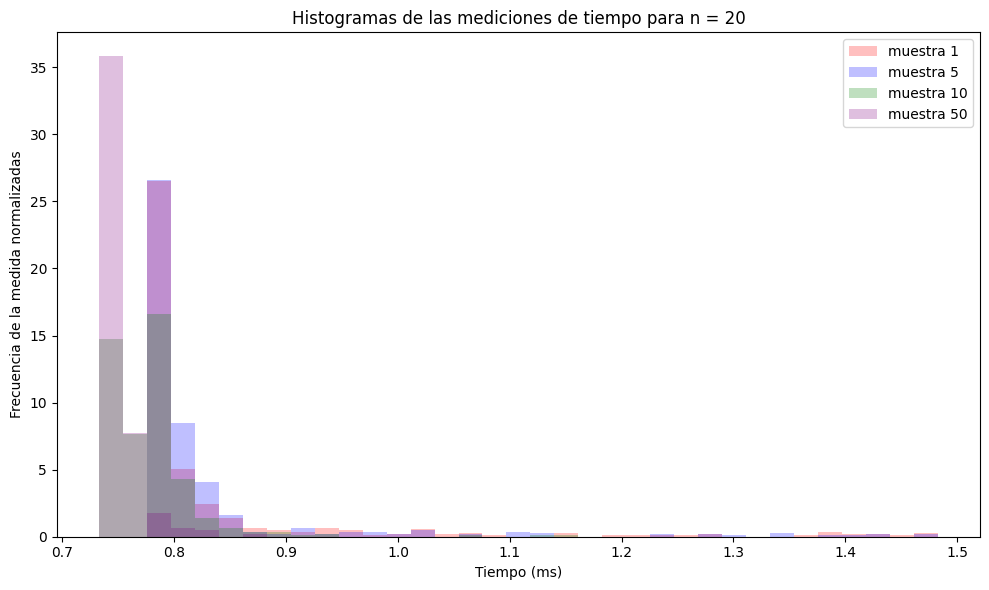

In [ ]:
colors = ['red', 'blue', 'green', 'purple']


plt.figure(figsize=(10, 6))
medidas = np.empty((len(batch_sizes), runs))

for i in range(len(batch_sizes)):
    medidas[i] = obtener_medidas_de(n, batch_sizes[i])

bins = np.linspace(np.min(medidas), np.max(medidas), 100)

for i in range(len(batch_sizes)):
    h, b = hacer_histograma(df, n, batch_sizes[i], bins)
    b = b[b < 1.5]
    h = h[:b.shape[0] - 1]
    plt.bar(b[:-1], h, width=bins[1]- bins[0], label=f"muestra {batch_sizes[i]}", align='center', fill=True, alpha=0.25, color=colors[i])

plt.xlabel("Tiempo (ms)")
plt.ylabel("Frecuencia de la medida normalizadas")
plt.title(f"Histogramas de las mediciones de tiempo para n = {n}")
plt.tight_layout()
plt.legend()
plt.show()

Podemos ver que para los batch sizes más grandes las mediciones se concentran mucho más en los valores más bajos. Esto tiene sentido porque al hacer un promedio de todas las mediciones en un batch, los outliers tendrán menos peso.

Además, y esto lo mencionamos en los ejercicios de más adelante, si hay un costo fijo por medir las ejecuciones, al obtener el promedio de las mediciones, estamos dividiendo el costo fijo por la cantidad de mediciones, por lo que es esperable que las mediciones con mayor batch size estén "movidas" un poco más a la izquierda.

## Ejercicio 4

Obtengamos algunos datos más descriptivos sobre la distribución de las muestras.

In [ ]:
resultados = []
for n in ns:
    for m in batch_sizes:
        medidas = obtener_medidas_de(n, m)

        resultados.append({
            "n": n,
            "m": m,
            "media": np.mean(medidas),
            "mediana": np.median(medidas),
            "desviacion estandar": np.std(medidas),
            "intercuartil": np.percentile(medidas, 75) - np.percentile(medidas, 25)
        })

datos = pd.DataFrame(resultados)
datos

,n,m,media,mediana,desviacion estandar,intercuartil
0,2,1,0.000538,0.000488,0.000219,0.000145
1,2,5,0.000740,0.000748,0.000377,0.000210
2,2,10,0.000741,0.000676,0.000401,0.000011
3,2,50,0.000299,0.000301,0.000066,0.000003
4,4,1,0.000800,0.000673,0.000594,0.000032
5,4,5,0.000448,0.000419,0.000174,0.000005
6,4,10,0.000743,0.000719,0.000306,0.000195
7,4,50,0.000402,0.000381,0.000121,0.000003
8,10,1,0.006765,0.006538,0.001336,0.000063
9,10,5,0.006596,0.006474,0.000475,0.000077


Podemos notar que se mantiene una tendencia donde la desviación estándar baja al aumentar el batch size, lo que se condice con las conclusiones obtenidas anteriormente al comparar las distribuciones de las mediciones por su batch size.

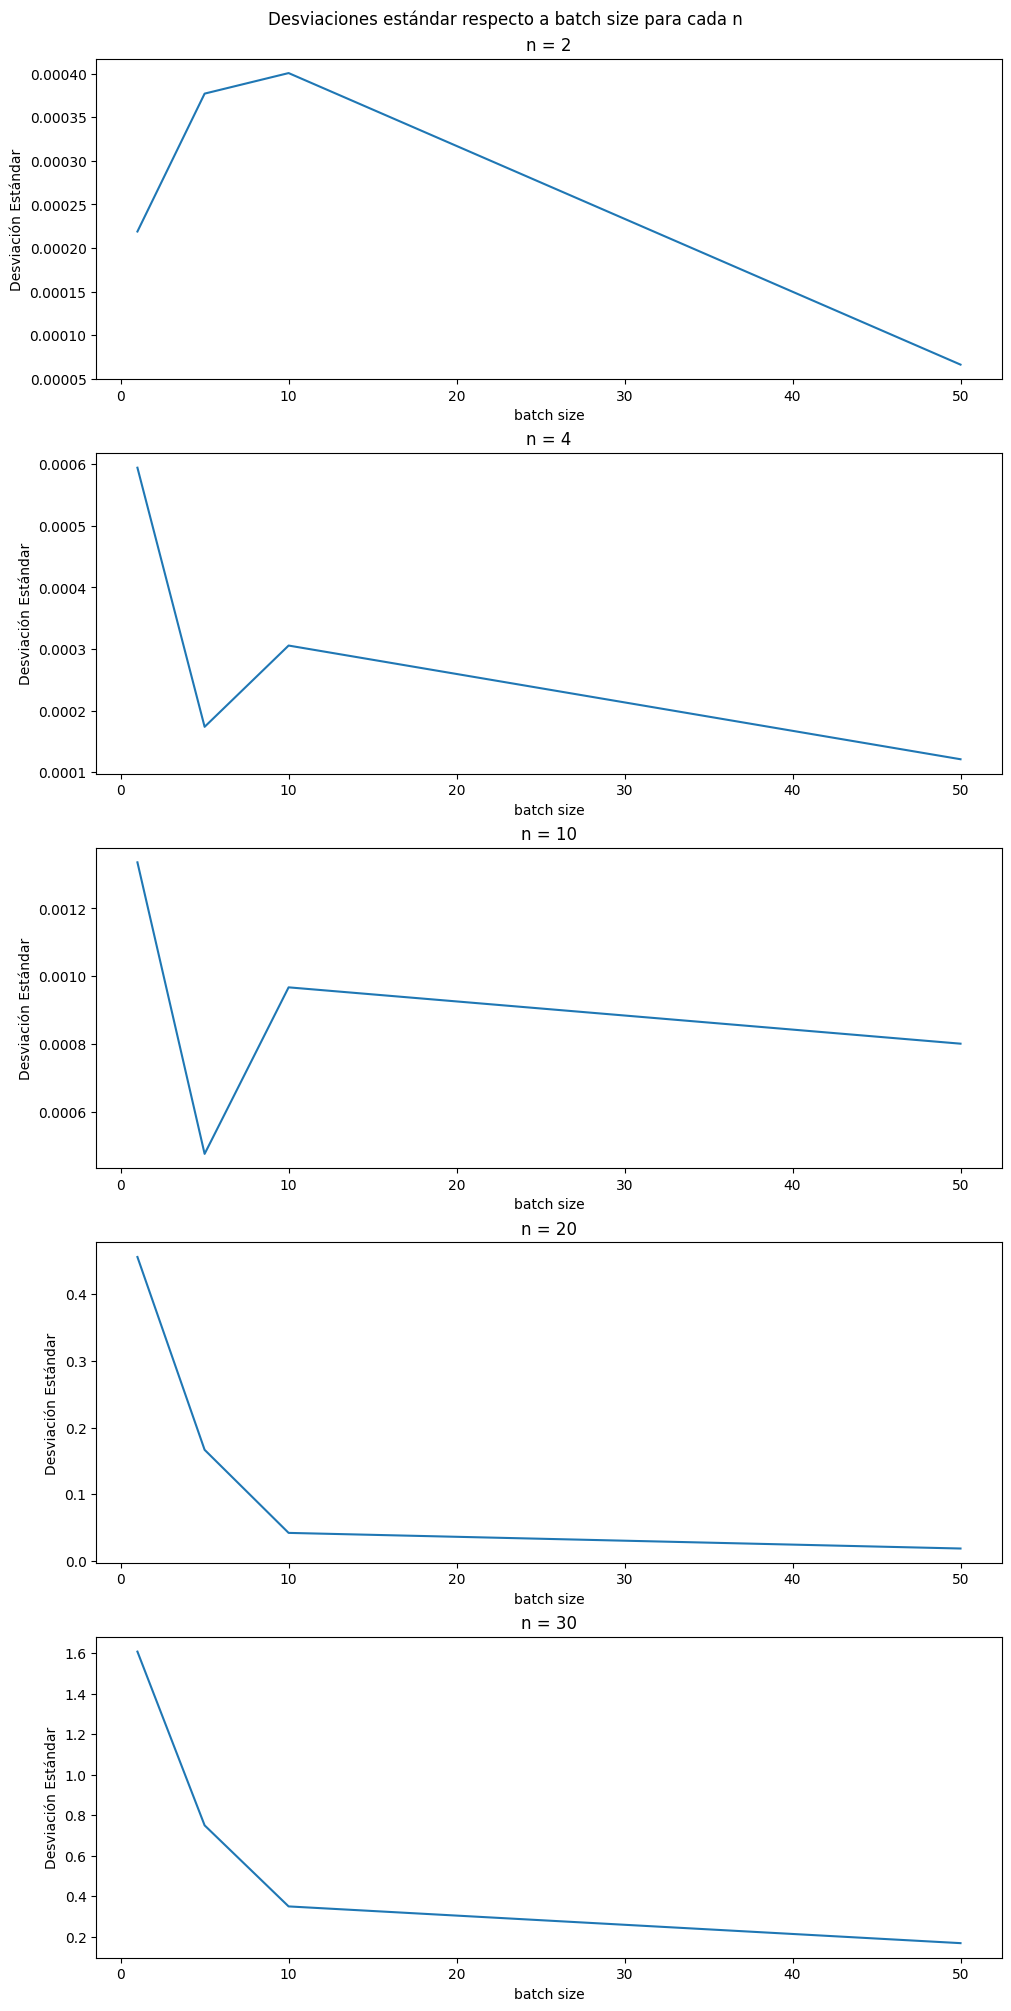

In [ ]:
fig, axs = plt.subplots(len(ns), 1, figsize=(10, 20), constrained_layout=True)
for (i, n) in enumerate(ns):
    datos_n = datos[datos["n"] == n]
    x = datos_n["m"]
    y = datos_n["desviacion estandar"]
    axs[i].plot(x, y)
    axs[i].set_title(f"n = {n}")
    axs[i].set_xlabel("batch size")
    axs[i].set_ylabel("Desviación Estándar")

plt.suptitle("Desviaciones estándar respecto a batch size para cada n")
plt.show()

Con esto podemos ver más claramente que, aunque con cierto ruido, la tendencia apunta que al aumentar el batch size se reduce la desviación estándar y por lo tanto la varianza también.

Veamos ahora además si era cierta nuestra afirmación sobre que a mayores batch sizes las medias muestrales disminuyen.


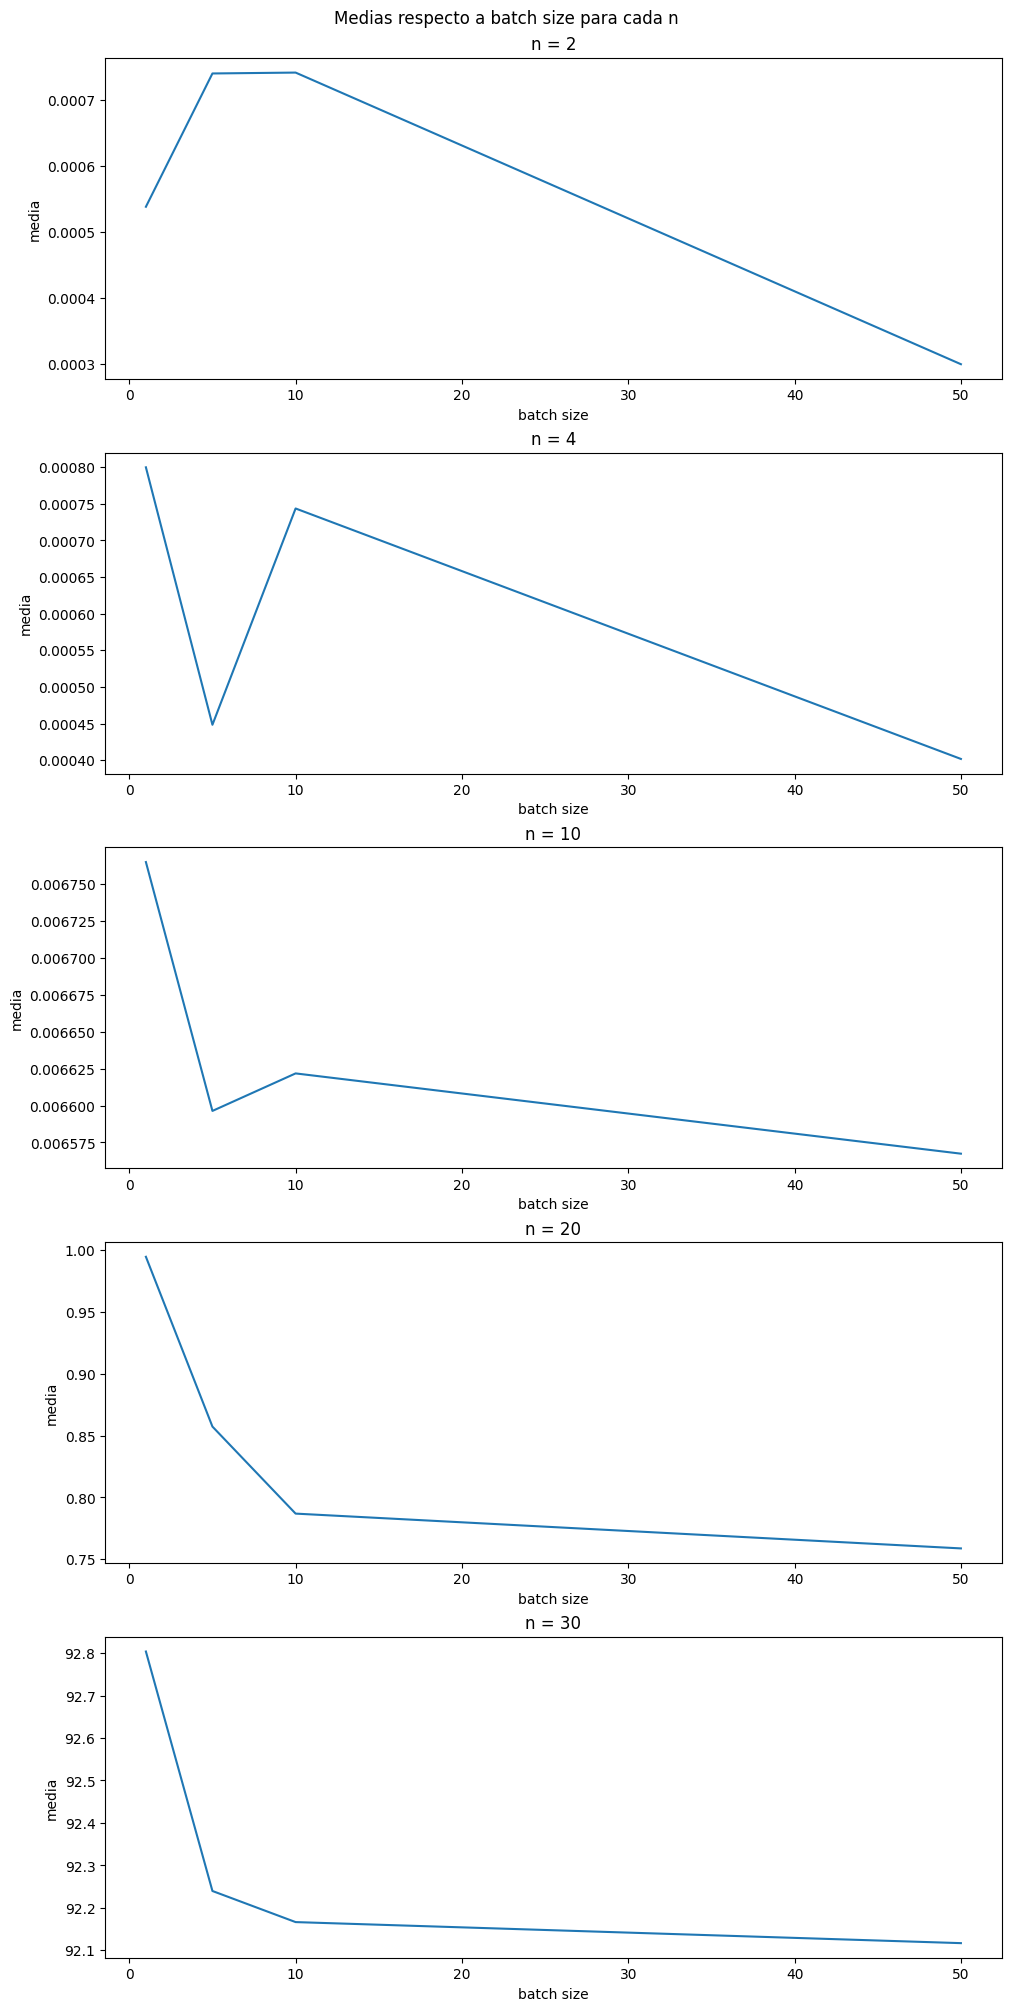

In [ ]:
fig, axs = plt.subplots(len(ns), 1, figsize=(10, 20), constrained_layout=True)
for (i, n) in enumerate(ns):
    datos_n = datos[datos["n"] == n]
    x = datos_n["m"]
    y = datos_n["media"]
    axs[i].plot(x, y)
    axs[i].set_title(f"n = {n}")
    axs[i].set_xlabel("batch size")
    axs[i].set_ylabel("media")

plt.suptitle("Medias respecto a batch size para cada n")
plt.show()

En efecto, podemos ver (con algo de ruido para $n$ chico) que disminuye la media muestral al aumentar el batch size ($m$)

#Inferencia: Tiempo de ejecución individual (I)


## Ejercicio 5
Utliazamos el test de lilliefors para evaluar la normalidad de la variable tiempo. Este es un test para decidir, con parámetros desconocidos, si una muestra sigue una distribución normal.

Este da 2 valores:
- ksstat: El estadístico de Kolmogorov-Smirnov, que está entre 0 y 1, y mientras más se acerque a 1, más confianza tenemos de que la distribución subyacente es normal
- p-value: El p-value para la hipótesis nula de que la distribución subyacente de la muestra, es normal.

In [ ]:
resultados_lilliefors = []
for n in ns:
  for m in batch_sizes:
    medidas = obtener_medidas_de(n, m)
    ksstat,p = lilliefors(medidas)
    resultados_lilliefors.append({
        "n": n,
        "m": m,
        "ksstat": f"{ksstat: .4f}",
        "p-value": f"{p: .4f}"
    })

resultados_lilliefors = pd.DataFrame(resultados_lilliefors)
resultados_lilliefors

,n,m,ksstat,p-value
0,2,1,0.1878,0.0010
1,2,5,0.3468,0.0010
2,2,10,0.4833,0.0010
3,2,50,0.4181,0.0010
4,4,1,0.3975,0.0010
5,4,5,0.4744,0.0010
6,4,10,0.2498,0.0010
7,4,50,0.4783,0.0010
8,10,1,0.4147,0.0010
9,10,5,0.3770,0.0010


Podemos afirmar con bastante seguridad que las distribuciones no se aproximan a una distribución normal a partir de los tests realizados y que sería improbable obtener estos resultados si la distribución subyacente efectivamente fuera normal.

Esto se condice con lo observado a partir de los gráficos de la distribución de las mediciones.

## Ejercicio 6
Realizamos el *t-test* para comparar si las distribuciones tienen la misma media para la medición singular y el promedio de varias mediciones. Mientras más lejos esté $t$ de $0$, menos probable es que esto se cumpla.


In [ ]:
resultados_ttest = []

for n in ns:
  med_singulares = obtener_medidas_de(n,1)
  for m in batch_sizes:
    if m==1:
      continue
    med_multiples = obtener_medidas_de(n,m)

    t, p = sp.stats.ttest_ind(med_singulares, med_multiples)
    resultados_ttest.append({
        "n": n,
        "m": m,
        "t": f"{t: .4f}",
        "p-value": f"{p: .4f}"
    })

resultados_ttest = pd.DataFrame(resultados_ttest)
resultados_ttest

,n,m,t,p-value
0,2,5,-10.3489,0.0000
1,2,10,-9.9489,0.0000
2,2,50,23.3103,0.0000
3,4,5,12.6710,0.0000
4,4,10,1.8774,0.0608
5,4,50,14.6524,0.0000
6,10,5,2.6577,0.0080
7,10,10,1.9407,0.0526
8,10,50,2.8353,0.0047
9,20,5,6.3192,0.0000


Observamos que hay diferencias significativas entre las distribuciones de medición simple y en lote, con algunas excepciones llamativas para $n = 10$.

Con los resultados obtenidos, es poco probable que tengan medias cercanas o iguales las muestras de mediciones simples con las mediciones en lote.

Sospechamos que esto se debe a lo antes mencionado respecto del costo fijo, que al aplicar el promedio sobre la medición total hace que se "mueva" más a la izquierda la distribución y por lo tanto, la media también. Es posible que con los $n$ más pequeños afecte también los demás procesos y scheduling de la computadora.


#Bootstrapping

## Ejercicio 5bis


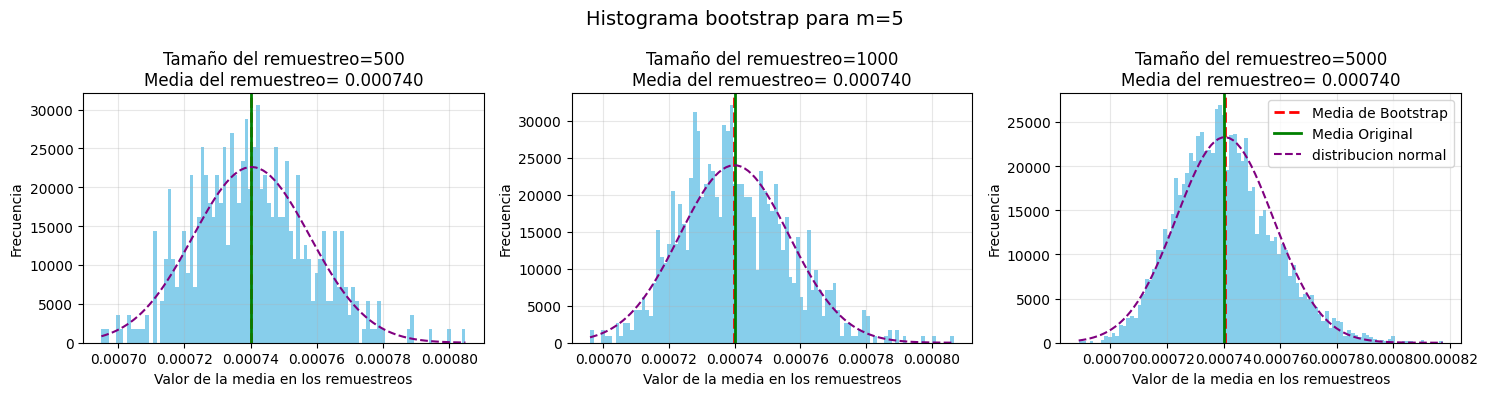

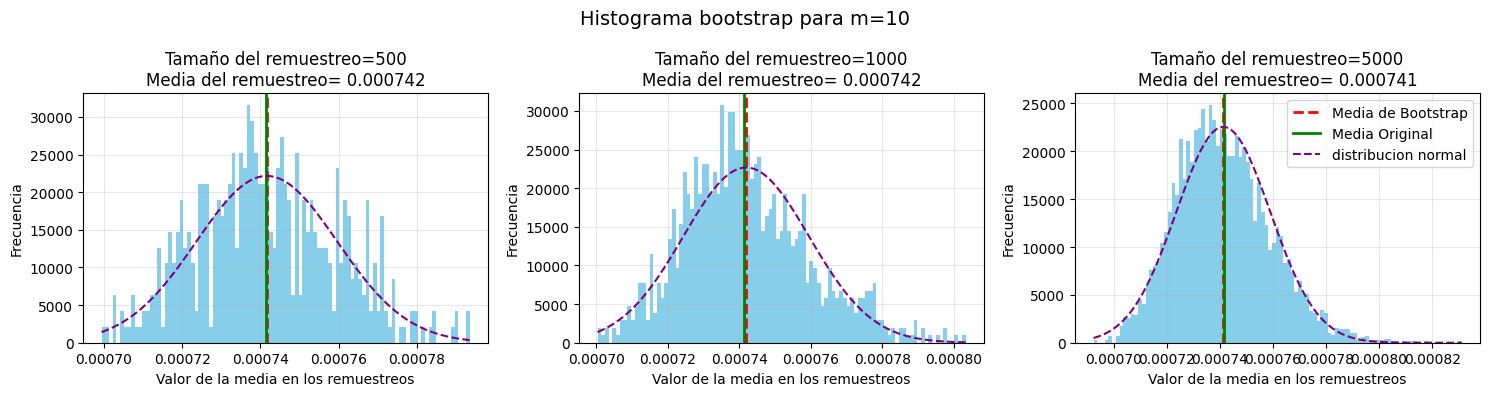

In [ ]:
def bootstrap_de_medias(n, m, M):
    medias = []
    medidas_boot = obtener_medidas_de(n, m)
    for i in range(M):
        y = np.random.choice(medidas_boot, size=len(medidas_boot), replace=True)
        medias.append(np.mean(y))
    return np.array(medias)

np.random.seed(42)
n = 2
valores_m = [5, 10]
valores_M = [500, 1000, 5000]
medias_boot=[]
for m in valores_m:
    fig, axes = plt.subplots(1, len(valores_M), figsize=(15,4))
    media_original = np.mean(obtener_medidas_de(n, m))

    for ax, M in zip(axes, valores_M):
        medias = bootstrap_de_medias(n, m, M)
        media_de_medias = np.mean(medias)
        medias_boot.append(medias)

        sigma = np.std(medias)


        maximo = np.max(medias)
        minimo = np.min(medias)
        tam = maximo - minimo
        bins = np.linspace(minimo, maximo, 100)

        ax.hist(medias, bins=bins, color="skyblue",fill=True, density=True)
        ax.axvline(media_de_medias, color="red", linestyle="--", linewidth=2, label=f"Media de Bootstrap")
        ax.axvline(media_original, color="green", linewidth=2, label=f"Media Original")


        y_normal = np.exp(-((bins - media_de_medias)**2) / (2*(np.var(medias)))) / (np.sqrt(2 * np.pi) * sigma)
        ax.plot(bins, y_normal, '--', label="distribucion normal", color="purple")

        ax.set_title(f"Tamaño del remuestreo={M}\nMedia del remuestreo={media_de_medias: 4f}")
        ax.set_xlabel("Valor de la media en los remuestreos")
        ax.set_ylabel("Frecuencia")
        ax.grid(alpha=0.3)


    plt.legend()
    fig.suptitle(f"Histograma bootstrap para m={m}", fontsize=14)
    plt.tight_layout()
    plt.show()


Observamos que, como ya sabemos por TCL la distribución de las medias muestrales (generadas por bootstrap), en efecto se comporta como una distribución normal.

Corroboremos esto con el test de normalidad de Shapiro, el cual devuelve:
- w : entre $0$ y $1$, cuanto más cerca del $1$, más probable que la distribución subyacente sea una normal
- p_value: entre $0$ y $1$, cuanto más cerca del $1$, la probabilidad de obtener los datos obtenidos, asumiendo $H_0$ verdadera (que la distribución subyacente es normal)

In [ ]:
resultados_shapiro = []
for i in range(len(medias_boot)):
    w,p = sp.stats.shapiro(medias_boot[i])
    resultados_shapiro.append({
        "n": n,
        "m": valores_m[i//3],
        "M": valores_M[i%3],
        "w": f"{w: .4f}",
        "p-value": f"{p: .4f}"
    })

resultados_shapiro = pd.DataFrame(resultados_shapiro)
resultados_shapiro

,n,m,M,w,p-value
0,2,5,500,0.9929,0.0186
1,2,5,1000,0.9895,0.0000
2,2,5,5000,0.9898,0.0000
3,2,10,500,0.9931,0.0217
4,2,10,1000,0.9843,0.0000
5,2,10,5000,0.9886,0.0000


Si observamos el estadístico $w$, se condice con los que pensabamos. Por otro lado, obtenemos un p_value muy bajo, pero esto puede ser porque la muestra es muy grande, y según la documentación, el p_value puede no ser preciso en esos casos.

Podemos usar también el test de lilliefors:

In [ ]:
resultados_lilliefors = []
for i in range(len(medias_boot)):
    ksstat,p = lilliefors(medias_boot[i])
    resultados_lilliefors.append({
        "m": valores_m[i//3],
        "M": valores_M[i%3],
        "ksstat": f"{ksstat: .4f}",
        "p-value": f"{p: .4f}"
    })

resultados_lilliefors = pd.DataFrame(resultados_lilliefors)
resultados_lilliefors

,m,M,ksstat,p-value
0,5,500,0.0327,0.2744
1,5,1000,0.0446,0.0010
2,5,5000,0.0334,0.0010
3,10,500,0.0376,0.1226
4,10,1000,0.0508,0.0010
5,10,5000,0.0344,0.0010


En este caso, el test nos dió que es poco probable que la distribución subyacente sea normal.

Por lo tanto, no podemos afirmar ni rechazar que la distribución es normal.

##Ejercicio 6 (bis)


Veamos de calcular intervalos mediante el ttest:

In [ ]:
nivel_de_confianza = 0.95
resultados_ttest = []

for i in range(len(valores_M)):
    results = sp.stats.ttest_ind(medias_boot[i], medias_boot[i+3], equal_var=False)
    resultados_ttest.append({
        "M": valores_M[i],
        "t": f"{results.statistic: .4f}",
        "p-value": f"{results.pvalue: .4f}",
        "Intervals": results.confidence_interval(confidence_level = nivel_de_confianza),
        "Rechaza o no H0":  "Rechaza" if (results.pvalue < 0.1) else "No rechaza"
    })

resultados_ttest = pd.DataFrame(resultados_ttest)
resultados_ttest

,M,t,p-value,Intervals,Rechaza o no H0
0,500,-1.2366,0.2165,"(-3.6096305919229337e-06, 8.188699231229394e-07)",No rechaza
1,1000,-2.6210,0.0088,"(-3.508362331910058e-06, -5.05231746889961e-07)",Rechaza
2,5000,-2.5326,0.0113,"(-1.5647918447427269e-06, -1.9935625517720668e...",Rechaza


Consideramos que este test rechaza la $H_0$ para los casos en donde las muestras son más grandes (1000 y 5000) porque la varianza en estos casos se reduce, y por lo tanto una diferencia que podia considerarse pequeña, es más significativa.



Ahora calculamos los intervalos "a mano":

In [ ]:
alpha = 5

for i in range(3):
    ts = []
    x = medias_boot[i]
    y = medias_boot[i+3]
    for j in range(valores_M[i]):
        x_rem_mean = np.random.choice(x, replace=True)
        y_rem_mean = np.random.choice(y, replace=True)
        t = x_rem_mean-y_rem_mean
        ts.append(t)

    ts = np.array(ts)
    t_iz = np.percentile(ts, alpha/2)
    t_der = np.percentile(ts, 100-alpha/2)

    t_mean = np.mean(ts)
    t_std = np.std(ts)
    ts[i]-t_mean

    print(f"Tamaño del remuestreo: {valores_M[i]}")
    print(f"t_iz: {t_iz}")
    print(f"t_der: {t_der}")
    if t_iz<0 and 0<t_der:
        print("No rechaza H0 \n")
    else:
        print("Rechaza H0 \n")




Tamaño del remuestreo: 500
t_iz: -4.622976927999989e-05
t_der: 4.3620537119999965e-05
No rechaza H0 

Tamaño del remuestreo: 1000
t_iz: -5.216114520499993e-05
t_der: 4.728055100000018e-05
No rechaza H0 

Tamaño del remuestreo: 5000
t_iz: -4.935640519499999e-05
t_der: 4.626676213500009e-05
No rechaza H0 



# Inferencia: tiempo de ejecución individual (II)



## Ejercicio 7
Obtengamos estimaciones para $\beta_0$ (ordenada al origen) y $\beta_1$ (pendiente) y veamos que los valores obtenidos tienen sentido mediante OLS, el cual nos permite también obtener otros datos como el intervalo de confianza de ambos estimadores que nos ayudarán a responder algunas preguntas.

De esta forma podemos estimar T el tiempo de corrida total como
$$ T = \hat{\beta_0} + \hat{\beta_1} * m $$

Calculemos los estimadores a mano:

In [ ]:
betas_0 = {}
betas_1 = {}
resultados = []
for n in ns:
  x = []
  y = []
  for m in batch_sizes:
    medidas = obtener_medidas_de(n, m)
    y.extend(medidas * m)
    x.extend([m] * len(medidas))


  beta_1 =  np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sum((x - np.mean(x))**2)
  beta_0 = np.mean(y) - beta_1 * np.mean(x)

  betas_1[n] = beta_1
  betas_0[n] = beta_0
  resultados.append({
      "n": n,
      "beta 0": beta_0,
      "beta 1": beta_1
  })

resultados = pd.DataFrame(resultados)
resultados

,n,beta 0,beta 1
0,2,0.002335,0.000262
1,4,0.001345,0.000382
2,10,0.000310,0.006562
3,20,0.371951,0.751566
4,30,0.673996,92.103143


Ahora usemos OLS:

In [ ]:
for n in ns:
  y = []
  x = []
  for m in batch_sizes:
    medidas = obtener_medidas_de(n, m)
    y.extend(medidas * m)
    x.extend([m] * len(medidas))

  modelo = OLS(y, add_constant(x))
  resultado = modelo.fit()
  print(resultado.params)
  print(resultado.summary())

[0.00233523 0.00026188]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     5124.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:00:58   Log-Likelihood:                 8647.9
No. Observations:                2000   AIC:                        -1.729e+04
Df Residuals:                    1998   BIC:                        -1.728e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023   9.37

Aunque no es aparente, para los $n$ más pequeños, con $n = 20$ y $30$, podemos ver que parece haber un costo fijo de ejecución, pues tenemos un $\beta_0$ (ordenada al origen) mayor que $0$, con un intervalo de confianza más bien alejado del $0$.

Notar que al ver las distribuciones obtenidas antes, para un mismo $n$, las que tienen mayor $ m$ están más concentradas en los valores bajos, lo que se condice con la idea de que hay un costo fijo de ejecución. Esto es porque guardamos el promedio, entonces al dividir el costo total por la cantidad de ejecuciones, el costo fijo es cada vez menos significativo en el resultado final.

El tiempo de ejecución individual sería el $\beta_1$ de cada $n$, la pendiente, pues es el ritmo por el que crece el tiempo de corrida total con respecto a $m$.

## Ejercicio 8
Grafiquemos los promedios y las funciones de la regresión lineal para comparar los resultados visualmente. Fijamos $n = 10$ y $N = 500$

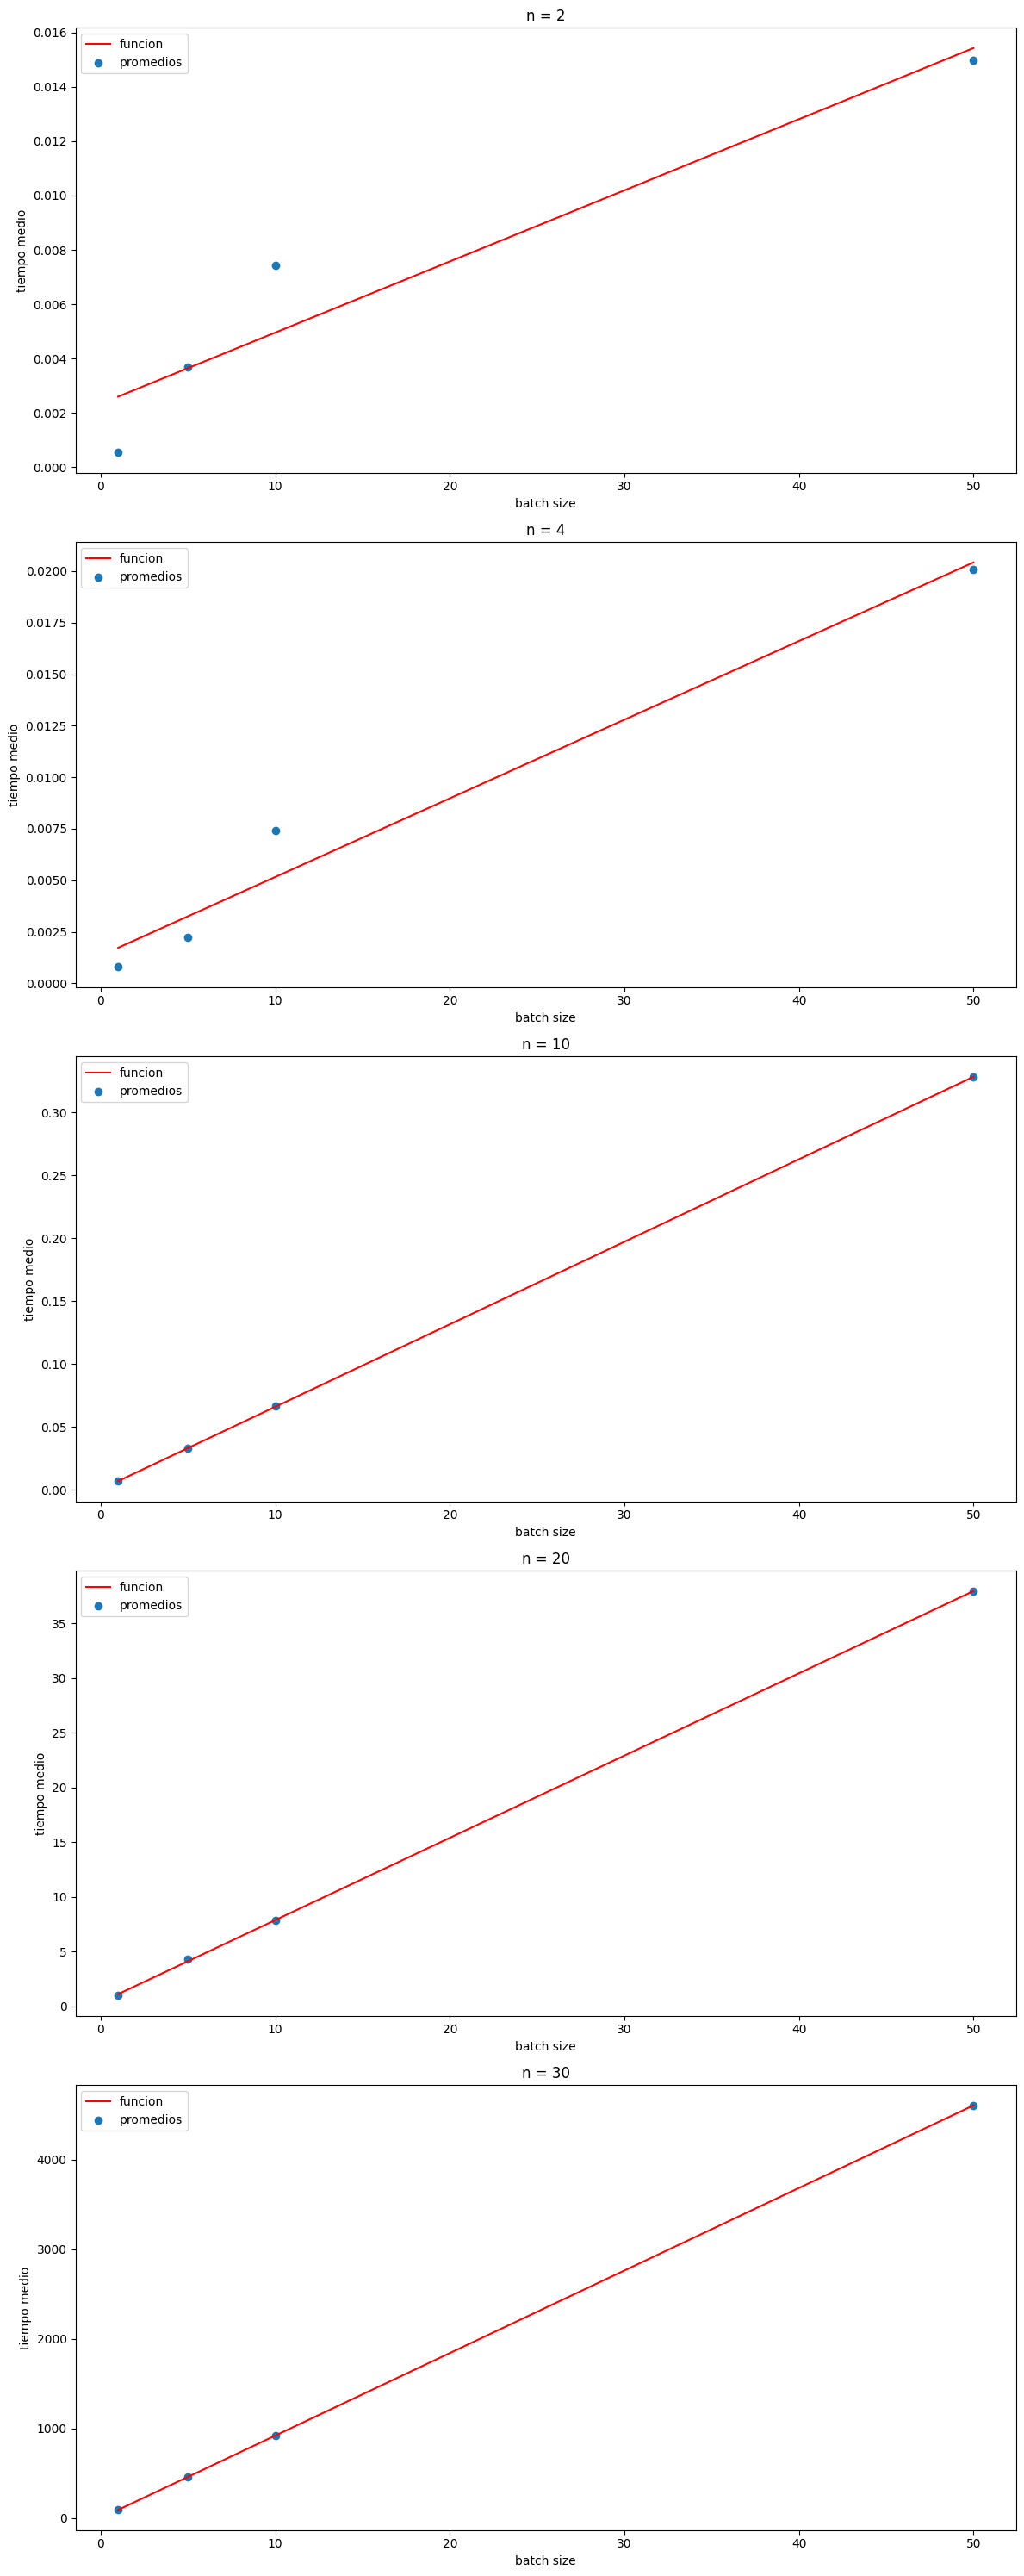

In [ ]:
#graficamos promedios


fig, axs = plt.subplots(len(ns), 1, figsize=(12, 30))

for (i, n) in enumerate(ns):
  N=500

  x = []
  y = []
  for m in batch_sizes:
    medidas = obtener_medidas_de(n, m)
    y.append(np.mean(medidas)* m )

  funcion = lambda m: betas_0[n] + betas_1[n] * m
  axs[i].plot(batch_sizes,funcion(np.array(batch_sizes)), color='red')
  axs[i].scatter(batch_sizes, y)
  axs[i].legend(["funcion", "promedios"])
  axs[i].set_title(f"n = {n}")
  axs[i].set_xlabel("batch size")
  axs[i].set_ylabel("tiempo medio")

plt.tight_layout()
plt.show()


Aunque notamos cierta diferencia para los $n$ más chicos, para los $n$ más grandes las funciones intersecan con los promedios obtenidos. Esto es esperable, porque como los $n$ más chicos mantienen promedios más pequeños de tiempo de ejecución, son más sensibles al ruido por otras tareas que ejecute la computadora, mientras que para valores más grandes, tarda más tiempo y por lo tanto no se ven tan afectados por el scheduling de la computadora que lo corre.

A partir de $n=10$, la regresión lineal interseca con todos los promedios, por lo que darán resultados similares y ninguno estaría sobrestimando más que el otro.


## **Ejercicio 9**
Para visualizar que el tiempo de ejecución individual no crece de forma lineal con respecto a $n$, podemos graficar el logaritmo del promedio del tiempo de ejecución medido con respecto a $n$, con $N = 500$ y $m = 1$.

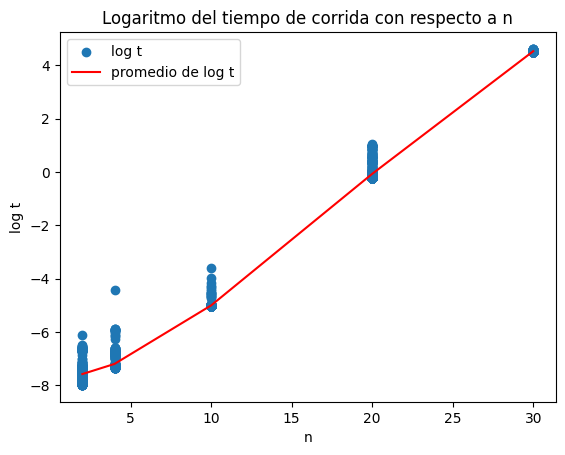

In [ ]:
x=[]
y=[]
means = []
for n in ns:
   medidas = obtener_medidas_de(n, 1)
   x.extend([n] * len(medidas))
   y.extend(np.log(medidas))
   means.append(np.mean(np.log(medidas)))
plt.scatter(x,y)
plt.plot(ns, means, color= 'red')
plt.legend(["log t", "promedio de log t"])
plt.title("Logaritmo del tiempo de corrida con respecto a n")
plt.ylabel('log t')
plt.xlabel('n')
plt.show()

Observamos que al aplicar logaritmo la relación entre $n$ y el logaritmo del tiempo de corrida es similar a una función lineal, por lo que la relación entre $n$ y el tiempo de corrida debería ser exponecial.

## Ejercicio 10

Calculamos la regresión lineal del logaritmo natural de $t$ (El tiempo de ejecución individual) con respecto a $n$, para los distintos batch sizes.

De nuevo calculémoslo también con OLS para verificar nuestros resultados y ver los intervalos de confianza.

In [ ]:
resultados = []
for m in batch_sizes:
  x = []
  y = []
  for n in ns:
    medidas = obtener_medidas_de(n, m)
    y.extend(np.log(medidas))
    x.extend([n] * len(medidas))

  beta_1 =  np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sum((x - np.mean(x))**2)
  beta_0 = np.mean(y) - beta_1 * np.mean(x)
  resultados.append({
      "m": m,
      "beta 0": beta_0,
      "beta 1": beta_1
  })

resultados = pd.DataFrame(resultados)
resultados

,m,beta 0,beta 1
0,1,-8.906577,0.442466
1,5,-8.988698,0.443620
2,10,-8.789857,0.434653
3,50,-9.444607,0.461688


In [ ]:
resultados_OLS = []
for m in batch_sizes:
  y = []
  x = []
  for n in ns:
    medidas = obtener_medidas_de(n, m)
    y.extend(np.log(medidas))
    x.extend([n] * len(medidas))

  modelo = OLS(y, add_constant(x))
  resultado = modelo.fit()
  resultados_OLS.append(resultado)
  print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 3.379e+05
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:01:00   Log-Likelihood:                -1247.8
No. Observations:                2500   AIC:                             2500.
Df Residuals:                    2498   BIC:                             2511.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.9066      0.013   -694.286      0.0

Notar que para todos los $m$ obtuvimos valores similares, lo que es esperable porque se refiere al tiempo de ejecución individual y solo debería verse afectado por el costo fijo de  ejecución, que notamos antes que era bastante pequeño.

Ahora apliquemos la función obtenida de la regresión lineal y comparémoslo a los valores de la muestra. Usamos los valores de $m = 1$, pero al ser todos bastante similares no debería hacer demasiada diferencia cuál elegimos.

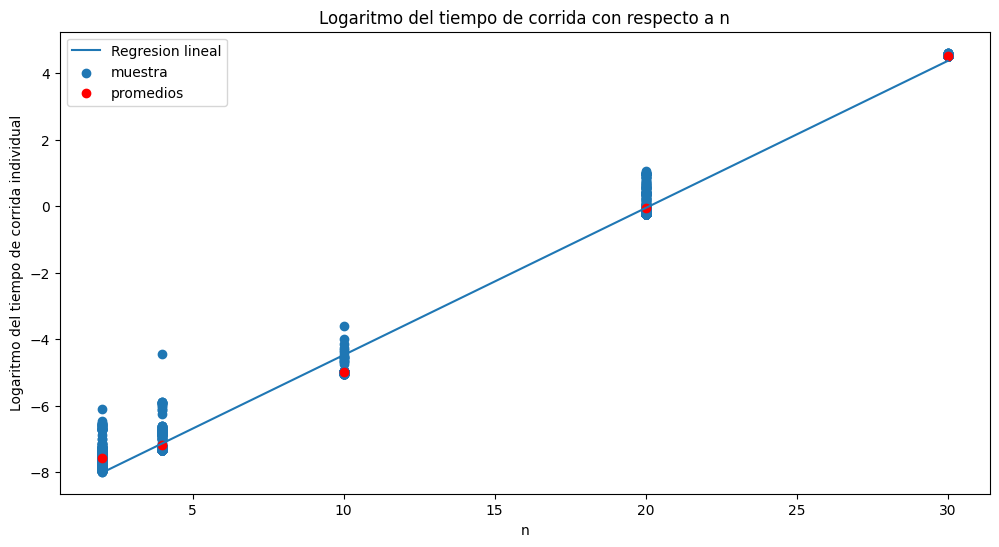

In [ ]:
plt.figure(figsize=(12, 6))
m = 1
beta_0 = resultados[resultados['m'] == m]['beta 0'].values[0]
beta_1 = resultados[resultados['m'] == m]['beta 1'].values[0]
f = lambda e: beta_0 + beta_1 * e
y = f(np.array(ns))
plt.plot(ns, y, label=f"Regresion lineal")

x = []
y = []
promedios = []
for n in ns:
    medidas = obtener_medidas_de(n, m)
    log_medidas = np.log(medidas)
    y.extend(log_medidas)
    x.extend([n] * len(medidas))
    promedios.append(np.mean(log_medidas))

plt.scatter(x, y, label="muestra")
plt.scatter(ns, promedios, color='red', label="promedios")
plt.title("Logaritmo del tiempo de corrida con respecto a n")
plt.xlabel("n")
plt.ylabel("Logaritmo del tiempo de corrida individual")
plt.legend()
plt.show()

Veamos de estimar $a$ para
$$t(n) = O(a^n)$$

Estimamos que
$$log ( t(n)) = \beta_1 * n + \beta_0$$
Pero como trabajamos con la complejidad, solo nos interesa el crecimiento de la función, así que usamos
$$log (t'(n)) = \beta_1 * n $$

Como tenemos $t(n) = a^n$
$$log(t'(n)) = log(a) * n $$

Entonces
$$ (log(t'(n))) / n = log(a) $$

Y por como estimamos $t'(n)$
$$ \beta_1 = log(a) $$

Por lo tanto
$$ \hat{a} = e^{\beta_1} $$

In [ ]:
a_hat = np.exp(beta_1)
a_hat

np.float64(1.5565404536079033)

Finalmente obtenemos que a debe ser aproximadamente 1,56, que es bastante cercano al número áureo.

Ahora calculemos un intervalo de confianza para a a partir de beta.

Buscamos $a_{0.025} a_{0.975}$ tal que
$$ P(a_{0.025} < \hat{a} < a_{0.975}) = 0.95 $$

Por como calculamos $\hat{a}$
$$ \hat{a} = e^{\beta_1} $$

Entonces lo remplazamos en la desigualdad, pues conocemos el intervalo de confianza de $\beta_1$ encontrado con OLS.

$$ a_{0.025} < e^{\beta_1} < a_{0.975} $$
$$ ln(a_{0.025}) < \beta_1 < ln(a_{0.975}) $$

Llamemos a ambos extremos del intervalo de confianza de $\beta_1$ $b_{0.025}$ $b_{0.975}$

Obtenemos finalmente que
$$ a_{0.025} = e^{b_{0.025}} $$
$$ a_{0.975} = e^{b_{0.975}} $$

In [ ]:
intervalo_de_confianza = resultados_OLS[0].conf_int(alpha=0.05)
intervalo_a = np.exp(intervalo_de_confianza[1])
intervalo_a

array([1.55421874, 1.55886563])

Con esto observamos que nuestro estimador cae dentro del intervalo de confianza, dando más seguridad de que efectivamente está bien calculado.